In [17]:
study_name = "arch_simple_glims_16"
results_path = f"results/{study_name}"
target_labels = ["diffusion", "proliferation"]
problem_type = "regression"
data_type = "glims"

In [18]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score

from latent_model.temporal_prediction import create_models_list, create_loaders

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
"""Utility Functions"""
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity plot for {label_type}", fontsize=24)
    plt.xlabel("True proliferation", fontsize=24)
    plt.ylabel("Predicted proliferation", fontsize=24)
    plt.grid(alpha=0.3)
    plt.show()

def plot_classification_results(y_true, y_pred, label_type, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, colorbar=False)
    plt.title(label_type)
    plt.show()

In [20]:
loaders = create_loaders(results_path, seq_len=9)
temporal_models = {}
for model_name in os.listdir(results_path):
    temporal_models[model_name] = {}
    model_path = f"{results_path}/{model_name}/_best_model"
    for dataset_name in os.listdir(model_path):
        loader = loaders[model_name][dataset_name]
        num_dims = loader.num_dims
        temporal_models[model_name][dataset_name] = create_models_list(
            input_size=num_dims, output_size=1, classification=False
        )

def transform_sample_id(sample_id):
    return torch.Tensor([float(arr.split("_")[1]) for arr in sample_id])

In [21]:
best_models = {}
patience = 5 
max_epochs = 50

for model_name, dataset in loaders.items():
    best_models[model_name] = {}
    for dataset_name, loader in dataset.items():
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        for model in temporal_models[model_name][dataset_name]:
            best_model = None
            best_loss = float("inf")
            no_improvement_count = 0
            # Train
            model.train()
            for epoch in range(max_epochs):
                epoch_loss = 0.0
                for embeddings, sample_id in train_loader:
                    x_batch = embeddings
                    y_batch = transform_sample_id(sample_id)

                    model.optimizer.zero_grad()
                    y_pred = model(x_batch)
                    loss = model.criterion(y_pred.flatten(), y_batch)
                    loss.backward()
                    model.optimizer.step()
                    epoch_loss += loss.item()
                epoch_loss /= len(train_loader)
                # Eval
                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        x_batch = embeddings
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(x_batch)
                        val_loss += model.criterion(y_pred.flatten(), y_batch).item()

                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_model = model
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1

                if no_improvement_count >= patience:
                    break

            best_models[model_name][dataset_name] = best_model
print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

Training complete
Training samples: 256
Validation samples: 64
Testing samples: 80


R² for ae | glims_128: -0.1698


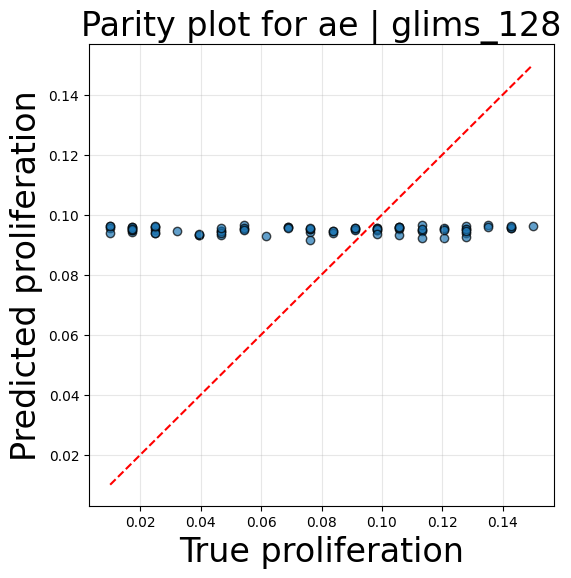

R² for cae | glims_128: -7.7964


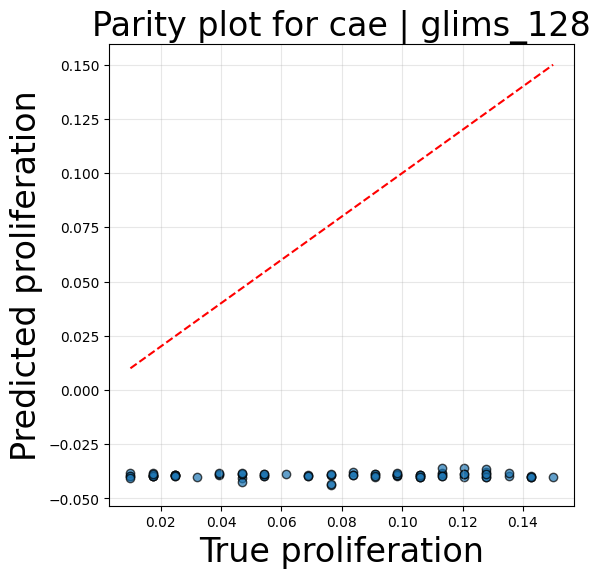

R² for neuralop | glims_128: -0.0099


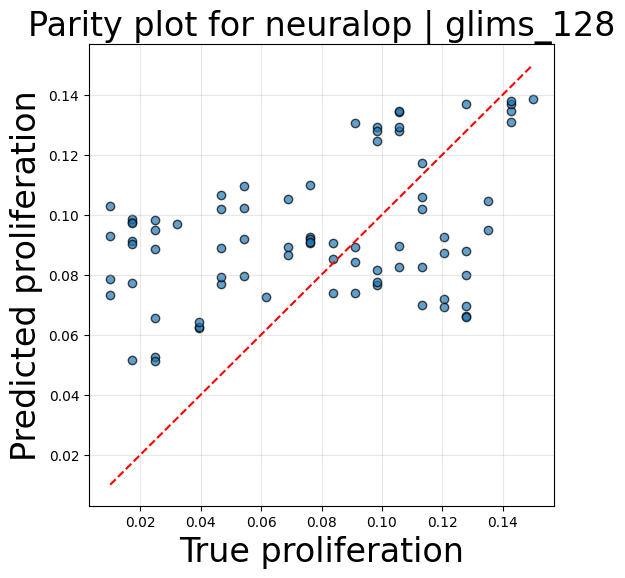

In [31]:
for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        y_true_labels = []
        y_pred_labels = []

        # Test
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = embeddings
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
        
        r2 = r2_score(y_true_labels, y_pred_labels)
        print(f"R² for {model_name} | {dataset_name}: {r2:.4f}")

        plot_regression_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}")